# Fake News detection 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
fake.shape

(23481, 4)

In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
true.shape

(21417, 4)

In [7]:
fake["label"] = 0
true["label"] = 1

Combinig datasets

In [8]:
data = pd.concat([fake, true], axis=0)

In [9]:
#shuffle
data = data.sample(frac=1).reset_index(drop=True)

In [10]:
data = data[["text", "label"]]

In [11]:
#ch3eck
data.shape

(44898, 2)

In [12]:
data.head()

,text,label
0,The former NPR CEO Ken Stern ditches and switc...,0
1,"On Sunday, during a panel segment on CNN s Sta...",0
2,"At least 27 people, including children, were m...",0
3,Donald Trump made an appearance last night on ...,0
4,PARIS (Reuters) - France said on Wednesday it ...,1


In [13]:
##text cleaning

In [14]:
import re

def clean_text(text):
    text = text.lower()  
    text = re.sub(r'\W', ' ', text)  
    text = re.sub(r'\d', ' ', text)  
    text = re.sub(r'\s+', ' ', text) 
    return text

In [15]:
data["text"] = data["text"].apply(clean_text) # cleaning

In [16]:
data["text"].head()

0    the former npr ceo ken stern ditches and switc...
1    on sunday during a panel segment on cnn s stat...
2    at least people including children were murder...
3    donald trump made an appearance last night on ...
4    paris reuters france said on wednesday it want...
Name: text, dtype: object

TF-IDF text to vector conversion

In [18]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,      # remove rare words
    max_df=0.8     # remove overly common words
)

X = vectorizer.fit_transform(data["text"])
Y = data["label"]

splitting data

In [19]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y ,test_size=0.2, random_state=2)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
Y_prediction = model.predict(X_test)

In [22]:
##accuracy scoreee

In [23]:
print("Accuracy is: ", accuracy_score(Y_test, Y_prediction))

Accuracy is:  0.9900890868596882


# Precision,recall, F1 score

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
print(confusion_matrix(Y_test, Y_prediction))
print(classification_report(Y_test, Y_prediction))

[[4717   48]
 [  41 4174]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4765
           1       0.99      0.99      0.99      4215

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [26]:
print("Train Accuracy:", model.score(X_train, Y_train))
print("Test Accuracy:", model.score(X_test, Y_test))

Train Accuracy: 0.9924271952781335
Test Accuracy: 0.9900890868596882


In [27]:
##predict if real or fake

In [28]:
def predict_news(text):
    #1
    cleaned_text = clean_text(text)
    #2
    vectorized_text = vectorizer.transform([cleaned_text])
    #3
    prediction = model.predict(vectorized_text)
    probability = model.predict_proba(vectorized_text)[0]
   #4
   # if prediction[0]==1:
   #     return "REAL NEWSSSS"
   # else:
   #    return "FAKE NEWSSSS"

In [29]:
print(predict_news("Government announces new economic reforms"))

None


In [30]:
print(predict_news("Reuters: New policy introduced by US government"))

None


In [31]:
print(predict_news("Aliens have landed in New York City!!!"))

None


In [32]:
print(predict_news("Donald trump is a donkey"))

None


In [33]:
## confidence coree

In [34]:
def predict_news(text):
    # 1. Preprocess and transform
    cleaned_text = clean_text(text)
    vectorized_text = vectorizer.transform([cleaned_text])
    
    # 2. Get probabilities
    # We only need to call predict_proba once
    probs = model.predict_proba(vectorized_text)[0]
    
    # Assuming index 1 is 'Real' and index 0 is 'Fake'
    real_prob = probs[1]
    
    # 3. Custom Threshold Logic
    # Using 0.6 instead of the default 0.5 to be more conservative
    if real_prob > 0.6:
        prediction = 1
        confidence = real_prob
    else:
        prediction = 0
        confidence = probs[0] # Probability of being Fake
    
    # 4. Output Formatting
    if prediction == 1:
        return f"REAL NEWS (Confidence: {confidence:.2f})"
    else:
        return f"FAKE NEWS (Confidence: {confidence:.2f})"

In [35]:
## basic test cases

In [36]:
print(predict_news("Government announces new tax reforms for 2026"))
print(predict_news("Aliens have landed and taken over the White House"))
print(predict_news("The stock market saw a significant increase today according to Reuters"))
print(predict_news("Scientists confirm drinking coffee makes you immortal"))

REAL NEWS (Confidence: 0.71)
FAKE NEWS (Confidence: 0.93)
REAL NEWS (Confidence: 0.72)
FAKE NEWS (Confidence: 0.91)


In [37]:
print(predict_news("New study shows economic growth may slow next year"))
print(predict_news("Breaking: secret government project revealed by anonymous source"))

FAKE NEWS (Confidence: 0.72)
FAKE NEWS (Confidence: 0.95)


In [38]:
print(predict_news("Good question — this is where most peopleee"))

FAKE NEWS (Confidence: 0.97)


In [39]:
user_input = input("Enter a news headline or article: ")
print(predict_news(user_input))

Enter a news headline or article: trump is dead
FAKE NEWS (Confidence: 0.92)


In [40]:
## vishualizing the logistic regression

In [41]:
#logistic regression has weights--- +ve for real
                                  # -ve for fake            

In [42]:
import matplotlib.pyplot as plt

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def plot_explanation(text, top_n=10):
    cleaned_text = clean_text(text)
    vectorized_text = vectorizer.transform([cleaned_text])
    
    feature_names = vectorizer.get_feature_names_out()
    coefficients = model.coef_[0]
    
    # Convert sparse → dense safely
    vector = vectorized_text.toarray()[0]
    
    contributions = []
    
    for idx, value in enumerate(vector):
        if value != 0:  # only words present
            word = feature_names[idx]
            weight = coefficients[idx]
            contribution = weight * value
            contributions.append((word, contribution))
    
    # Sort contributions
    contributions = sorted(contributions, key=lambda x: x[1])
    
    top_fake = contributions[:top_n]
    top_real = contributions[-top_n:]
    
    words = [w for w, _ in top_fake + top_real]
    scores = [s for _, s in top_fake + top_real]
    
    colors = ['red' if s < 0 else 'green' for s in scores]
    
    plt.figure()
    plt.barh(words, scores, color=colors)
    plt.title("Word Contributions (Red = Fake, Green = Real)")
    plt.xlabel("Contribution Score")
    plt.show()

# stress test


FAKE NEWS (Confidence: 0.71)


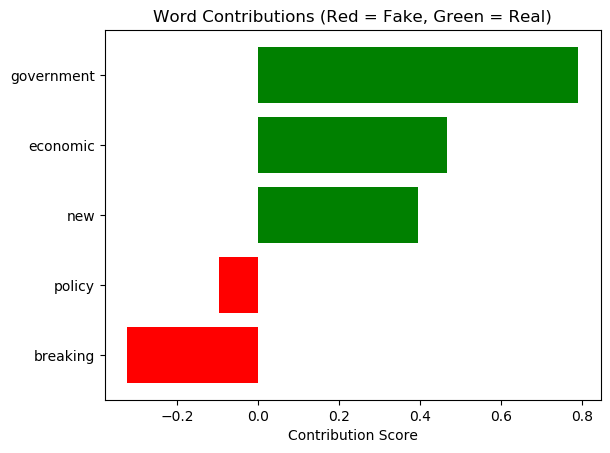

In [44]:
text = "Breaking: Government announces new economic policy"
print(predict_news(text))
plot_explanation(text)

REAL NEWS (Confidence: 0.71)


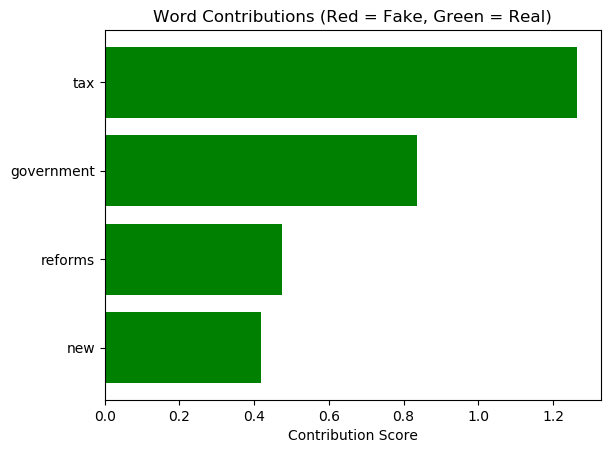

In [45]:
text = "Government announces new tax reforms for 2026"

print(predict_news(text))
plot_explanation(text)

FAKE NEWS (Confidence: 0.94)


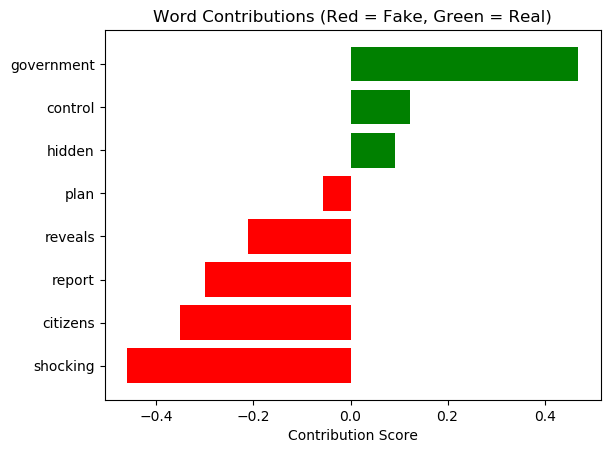

In [46]:
print(predict_news("Shocking report reveals hidden government plan to control citizens"))
plot_explanation("Shocking report reveals hidden government plan to control citizens")

FAKE NEWS (Confidence: 0.83)


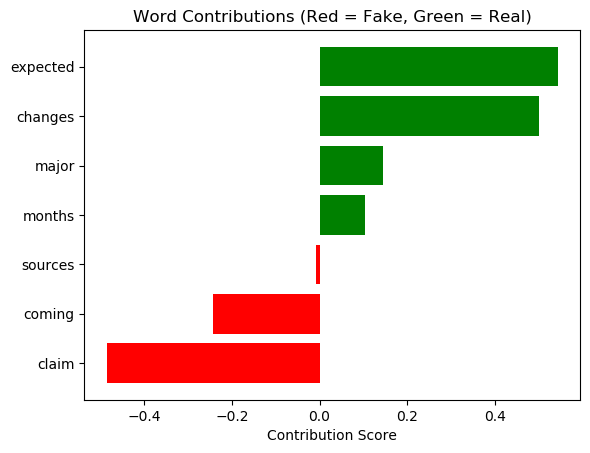

In [47]:
print(predict_news("Sources claim that major changes are expected in the coming months"))
plot_explanation("Sources claim that major changes are expected in the coming months")

FAKE NEWS (Confidence: 0.61)


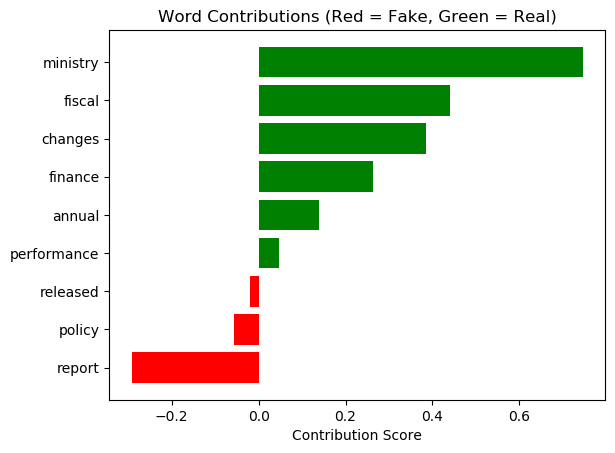

In [48]:
print(predict_news("The finance ministry released its annual report outlining fiscal performance and policy changes"))
plot_explanation("The finance ministry released its annual report outlining fiscal performance and policy changes")

In [49]:
test_cases = [
    "Shocking report reveals hidden government plan",
    "Sources claim major changes expected",
    "Finance ministry releases annual report",
    "Hot water cures all diseases instantly",
    "Unverified claim about economic collapse",
    "Reuters reports conspiracy confirmed"
]

for text in test_cases:
    print("\nTEXT:", text)
    print("PREDICTION:", predict_news(text))


TEXT: Shocking report reveals hidden government plan
PREDICTION: FAKE NEWS (Confidence: 0.93)

TEXT: Sources claim major changes expected
PREDICTION: FAKE NEWS (Confidence: 0.79)

TEXT: Finance ministry releases annual report
PREDICTION: FAKE NEWS (Confidence: 0.69)

TEXT: Hot water cures all diseases instantly
PREDICTION: FAKE NEWS (Confidence: 0.94)

TEXT: Unverified claim about economic collapse
PREDICTION: FAKE NEWS (Confidence: 0.90)

TEXT: Reuters reports conspiracy confirmed
PREDICTION: REAL NEWS (Confidence: 0.92)


In [50]:
print(data["label"].value_counts())

0    23481
1    21417
Name: label, dtype: int64


In [51]:
print(predict_news("Government announces new tax reforms for 2026"))

REAL NEWS (Confidence: 0.71)


In [52]:
#The model tends to misclassify neutral or formal statements as fake due to reliance on word frequency patterns.
#It also overweights certain keywords like “Reuters,” leading to incorrect classifications in adversarial cases

In [53]:
##Normal prediction
##Explanation graph

In [54]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [55]:
import os
print(os.getcwd())

C:\Users\acsma
